In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [4]:
# Load dataset
import pandas as pd
df = pd.read_csv("Financial_Management_Dataset.csv")
# Check data
df.head()

,Transaction ID,Date,Account Name,Department,Transaction Type,Category,Amount,Currency,Approved By,Notes
0,TXN100000,2023-01-01,Investment Account,R&D,Debit,Salary,3965.77,USD,CFO,Quarterly Bonus
1,TXN100001,2023-01-02,Operating Account,R&D,Debit,Purchase,4470.17,INR,Manager C,Ad-hoc Expense
2,TXN100002,2023-01-03,Investment Account,Operations,Debit,Utilities,2225.71,USD,Manager C,Ad-hoc Expense
3,TXN100003,2023-01-04,Investment Account,Marketing,Debit,Salary,4558.72,INR,Manager C,Quarterly Bonus
4,TXN100004,2023-01-05,Operating Account,HR,Credit,Investment,1948.86,EUR,Manager C,Project Allocation


In [6]:
# Data Cleaning
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df["YearMonth"] = df["Date"].dt.to_period("M")


In [7]:
# Q1. What are the monthly trends in spending and income across different departments?

monthly_trends = (
    df.groupby(
        ["YearMonth", "Department", "Transaction Type"]
    )["Amount"]
    .sum()
    .reset_index()
)

monthly_trends.head()


,YearMonth,Department,Transaction Type,Amount
0,2023-01,HR,Credit,11426.99
1,2023-01,Marketing,Credit,8217.30
2,2023-01,Marketing,Debit,18667.53
3,2023-01,Operations,Credit,7176.36
4,2023-01,Operations,Debit,6984.50


In [8]:
# Q2. Which departments are consistently overshooting their budgets based on transaction categories?

debit_data = df[df["Transaction Type"] == "Debit"]

budget_analysis = (
    debit_data.groupby(
        ["Department", "Category"]
    )["Amount"]
    .sum()
    .reset_index()
    .sort_values("Amount", ascending=False)
)

print(budget_analysis.head())

    Department    Category     Amount
15  Operations      Salary  199763.54
26       Sales    Purchase  164917.53
23         R&D   Utilities  164235.61
18         R&D  Investment  162293.78
3           HR      Salary  162137.17


In [9]:
# Q3. What is the average monthly expenditure per account?

monthly_expense = (
    debit_data.groupby(
        ["YearMonth", "Account Name"]
    )["Amount"]
    .sum()
    .reset_index()
)

avg_expense = (
    monthly_expense.groupby("Account Name")["Amount"]
    .mean()
    .reset_index()
)

print("Q3. Average Monthly Expenditure")

print(avg_expense)

Q3. Average Monthly Expenditure
         Account Name        Amount
0  Investment Account  12124.183222
1   Operating Account  16103.126000
2     Payroll Account  14672.349667


NameError: name 'plt' is not defined

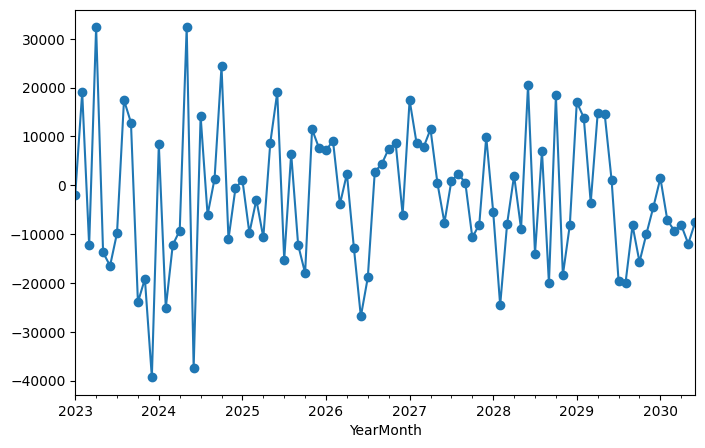

In [10]:
# CASH FLOW & LIQUIDITY

# Q4. What is the net cash flow (Credit - Debit) per month or quarter, and how does it vary by department or account?
    
credit_data = df[df["Transaction Type"] == "Credit"]

debit_data = df[df["Transaction Type"] == "Debit"]


# Monthly Credit Amount
monthly_credit = (
    credit_data.groupby("YearMonth")["Amount"]
    .sum()
)

# Monthly Debit Amount
monthly_debit = (
    debit_data.groupby("YearMonth")["Amount"]
    .sum()
)
# Net Cash Flow Calculation
net_cash_flow = monthly_credit - monthly_debit

net_cash_flow


# Cash Flow by Department

department_cash_flow = (
    df.groupby(
        ["Department", "Transaction Type"]
    )["Amount"]
    .sum()
    .unstack(fill_value=0)
)

department_cash_flow["Net Cash Flow"] = (
    department_cash_flow["Credit"]
    - department_cash_flow["Debit"]
)

department_cash_flow


# Cash Flow by Account

account_cash_flow = (
    df.groupby(
        ["Account Name", "Transaction Type"]
    )["Amount"]
    .sum()
    .unstack(fill_value=0)
)

account_cash_flow["Net Cash Flow"] = (
    account_cash_flow["Credit"]
    - account_cash_flow["Debit"]
)

account_cash_flow

# Net Cash Flow Visualization

net_cash_flow.plot(
    figsize=(8,5),
    marker="o"
)

plt.title("Monthly Net Cash Flow")
plt.xlabel("Month")
plt.ylabel("Cash Flow Amount")

plt.show()


In [16]:
# Q5. Categories contributing most to inflow and outflow

cash_categories = (
    df.groupby(
        ["Category", "Transaction Type"]
    )["Amount"]
    .sum()
    .reset_index()
)

cash_categories

,Category,Transaction Type,Amount
0,Investment,Credit,820205.25
1,Investment,Debit,652404.88
2,Maintenance,Credit,619778.76
3,Maintenance,Debit,611589.72
4,Purchase,Credit,455252.72
5,Purchase,Debit,667452.11
6,Salary,Credit,529647.13
7,Salary,Debit,690480.58
8,Travel,Credit,654201.68
9,Travel,Debit,624510.34


In [11]:
# QUESTION 6: Liquidity Risk Analysis

# Create Month column
df["Month"] = pd.to_datetime(df["Date"]).dt.to_period("M")

# Credit transactions
credit_data = (
    df[df["Transaction Type"] == "Credit"]
    .groupby("Month")["Amount"]
    .sum()
)

# Debit transactions
debit_data = (
    df[df["Transaction Type"] == "Debit"]
    .groupby("Month")["Amount"]
    .sum()
)

# Combine data
liquidity_risk = pd.DataFrame({
    "Credit": credit_data,
    "Debit": debit_data
}).fillna(0)

# Net Cash Flow
liquidity_risk["NetCashFlow"] = (
    liquidity_risk["Credit"] - liquidity_risk["Debit"]
)

print(liquidity_risk)

           Credit     Debit  NetCashFlow
Month                                   
2023-01  42443.12  44376.29     -1933.17
2023-02  43185.87  24175.21     19010.66
2023-03  28074.23  40378.44    -12304.21
2023-04  56849.79  24491.66     32358.13
2023-05  28636.49  42393.07    -13756.58
...           ...       ...          ...
2030-02  35484.68  42660.50     -7175.82
2030-03  33556.72  42860.80     -9304.08
2030-04  32289.27  40492.69     -8203.42
2030-05  30022.35  42007.72    -11985.37
2030-06  24312.98  31856.89     -7543.91

[90 rows x 3 columns]


In [12]:
7.	Which transaction categories (e.g., Salary, Travel) are showing an upward or downward trend in expenses?

# Debit transactions only
debit_data = df[df["Transaction Type"] == "Debit"]

# Monthly category expenses
expenses = (
    debit_data.groupby(
        ["YearMonth", "Category"]
    )["Amount"]
    .sum()
    .reset_index()
)

# Create trend dataframe
trend = (
    expenses.groupby("Category")["Amount"]
    .agg(["first", "last"])
    .reset_index()
)

# Upward or Downward
trend["Trend"] = trend.apply(
    lambda x: "Upward"
    if x["last"] > x["first"]
    else "Downward",
    axis=1
)

print(trend)

Object `expenses` not found.
      Category     first     last     Trend
0   Investment   8590.73  3407.77  Downward
1  Maintenance   1864.25  7511.09    Upward
2     Purchase  12514.82  4912.90  Downward
3       Salary  12353.58  7769.28  Downward
4       Travel  12802.16  7718.36  Downward
5    Utilities   4841.48   537.49  Downward


In [13]:
8.	Who are the top approvers (managers) with the highest approval volume or highest expense total?

top_approvers = (
    df.groupby("Approved By")["Amount"]
    .sum()
    .reset_index()
    .sort_values(by="Amount", ascending=False)
)

print("\nQ8. Top Approvers")
print(top_approvers.head(10))

Object `total` not found.

Q8. Top Approvers
  Approved By      Amount
2   Manager B  2017692.45
3   Manager C  1926754.25
0         CFO  1787582.98
1   Manager A  1782514.65


In [14]:
# Q9. Non-operational expense percentage

non_operational = [
    "Maintenance",
    "Travel",
    "Ad-hoc Expenses"
]

# Total spend
total_spend = df["Amount"].sum()

# Non-operational spend
non_operational_spend = (
    df[df["Category"].isin(non_operational)]["Amount"]
    .sum()
)

# Percentage calculation
percentage_spend = (
    non_operational_spend / total_spend
) * 100

print("Non-Operational Spend Percentage:", percentage_spend)


Non-Operational Spend Percentage: 33.40296350344373


In [15]:
# QUESTION 10: Departments with Unusual Transaction Frequency or High Amounts

department_analysis = (
    df.groupby("Department")["Amount"]
    .agg(
        TransactionFrequency = "count",
        TotalAmount = "sum"
    )
    .reset_index()
    .sort_values("TotalAmount", ascending=False)
)

department_analysis.head()

,Department,TransactionFrequency,TotalAmount
2,Operations,641,1661102.46
4,Sales,622,1582011.97
0,HR,590,1489702.46
3,R&D,589,1422395.82
1,Marketing,558,1359331.62


In [16]:
# QUESTION 11: Abnormal Transactions 

mean_amount = df["Amount"].mean()
std_amount = df["Amount"].std()

# Transactions greater than 2 standard deviations
abnormal_transactions = df[
    df["Amount"] > (mean_amount + 2 * std_amount)
]

abnormal_transactions.head()

,Transaction ID,Date,Account Name,Department,Transaction Type,Category,Amount,Currency,Approved By,Notes,Year,Month,YearMonth
1016,TXN200016,2025-01-17,Investment Account,HR,Credit,Utilities,5403.55,INR,Manager C,Monthly Bill,2025,2025-01,2025-01
1067,TXN200067,2025-03-09,Payroll Account,Sales,Debit,Purchase,5695.96,USD,Manager B,Monthly Bill,2025,2025-03,2025-03
1156,TXN200156,2025-06-06,Operating Account,Marketing,Credit,Utilities,5389.04,USD,Manager C,Monthly Bill,2025,2025-06,2025-06
1180,TXN200180,2025-06-30,Operating Account,HR,Credit,Purchase,5652.71,USD,Manager B,Monthly Bill,2025,2025-06,2025-06
1210,TXN200210,2025-07-30,Investment Account,R&D,Debit,Utilities,5441.35,EUR,CFO,Project Allocation,2025,2025-07,2025-07


In [19]:
# Q12. Forecast next month spending

from sklearn.linear_model import LinearRegression

# Monthly spending
monthly_spending = (
    df.groupby("YearMonth")["Amount"]
    .sum()
    .reset_index()
)

# Convert Period → int
monthly_spending["MonthIndex"] = range(len(monthly_spending))

X = monthly_spending[["MonthIndex"]]
y = monthly_spending["Amount"]

model = LinearRegression()
model.fit(X, y)

# Predict next month
next_month = pd.DataFrame({
    "MonthIndex": [len(monthly_spending)]
})

forecast = model.predict(next_month)

print("Next Month Forecast:", forecast[0])

Next Month Forecast: 73005.27013483146


In [20]:
# Q13. Credit and Debit trends across accounts

account_trends = (
    df.groupby(
        ["Account Name", "Transaction Type"]
    )["Amount"]
    .sum()
    .reset_index()
)

account_trends.head()

,Account Name,Transaction Type,Amount
0,Investment Account,Credit,1305002.72
1,Investment Account,Debit,1091176.49
2,Operating Account,Credit,1087655.75
3,Operating Account,Debit,1449281.34
4,Payroll Account,Credit,1260916.56


In [21]:
# QUESTION 14: Approvers Handling High-Amount Transactions

high_amount_transactions = (
    df.groupby(["Approved By", "Department"])["Amount"]
    .sum()
    .reset_index()
    .sort_values("Amount", ascending=False)
)

print(high_amount_transactions.head())

   Approved By  Department     Amount
12   Manager B  Operations  489548.65
2          CFO  Operations  480296.45
14   Manager B       Sales  468911.72
16   Manager C   Marketing  435627.23
17   Manager C  Operations  401215.52


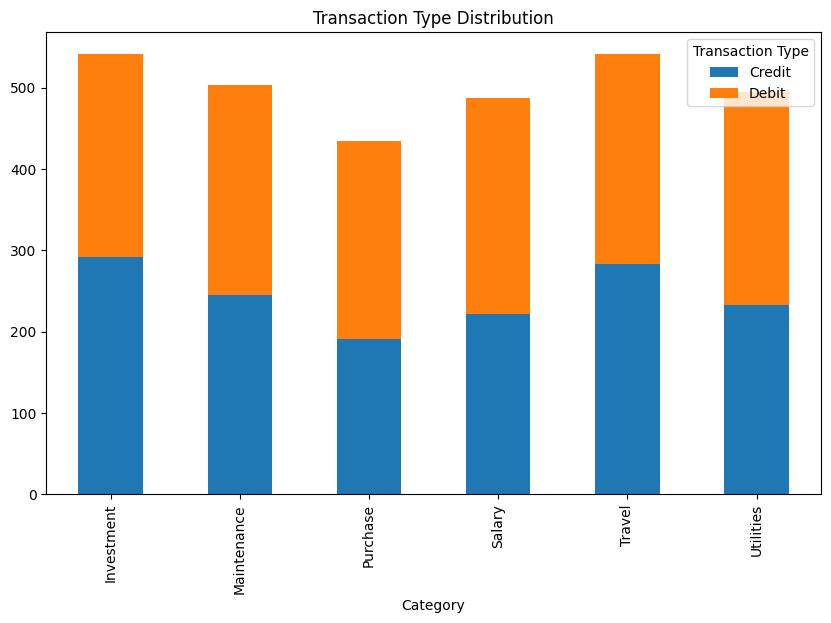

In [28]:

# Q15. Transaction type distribution

distribution = pd.crosstab(
    df["Category"],
    df["Transaction Type"]
)

distribution

# Transaction Distribution Chart

distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Transaction Type Distribution")

plt.show()
